In [27]:
# =============================================================================
# IMPORTS Y CONFIGURACIÓN
# =============================================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import json
import gc
import psutil
import os
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración para plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 7)

# Paths
RAW_DIR = Path("../data/raw/cluvi/")
OUTPUT_DIR = "../data/process/"  # Adaptado si es necesario
REPORT_DIR = Path("../reports/eda_cluvi/")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("="*80)
print("EDA COMPLETO Y MEJORADO - DATASET CLUVI (MENÚS Y CATEGORÍAS)")
print("="*80)

EDA COMPLETO Y MEJORADO - DATASET CLUVI (MENÚS Y CATEGORÍAS)


In [28]:
# =============================================================================
# FUNCIONES AUXILIARES
# =============================================================================

def save_report(data, filename, format='json'):
    """Guarda reportes en formato JSON o CSV"""
    filepath = REPORT_DIR / filename
    if format == 'json':
        with open(filepath, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    elif format == 'csv' and isinstance(data, (pl.DataFrame, pd.DataFrame)):
        if isinstance(data, pl.DataFrame):
            data.write_csv(filepath)
        else:
            data.to_csv(filepath, index=False)
    print(f"✓ Reporte guardado: {filepath}")

def plot_and_save(fig, filename):
    """Guarda figura y la muestra"""
    filepath = REPORT_DIR / filename
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfico guardado: {filepath}")
    plt.show()

def calculate_gini(counts):
    """Calcula el coeficiente de Gini para medir desbalance"""
    sorted_counts = np.sort(counts)
    n = len(counts)
    cumsum = np.cumsum(sorted_counts)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n

def print_section(title):
    """Imprime encabezado de sección"""
    print("\n" + "="*80)
    print(f"{title}")
    print("="*80)

def liberar_ram():
    """Libera RAM y muestra uso actual"""
    process = psutil.Process(os.getpid())
    mem_antes = process.memory_info().rss / 1024 / 1024  # MB
    
    # Colectar garbage
    gc.collect()
    
    mem_despues = process.memory_info().rss / 1024 / 1024
    print(f"RAM liberada: {mem_antes - mem_despues:.2f} MB")
    print(f"RAM actual: {mem_despues:.2f} MB")

In [29]:
!pwd

/home/daniel-linux/Tesis/Recolectar_Datos/notebooks


In [30]:
# =============================================================================
# CARGA DE DATOS (concatenando todos los CSVs)
# =============================================================================
print_section("CARGA DE DATOS (Todos los CSVs en ../data/raw/CLuvi/)")

import glob
import os

print(f"pwd {os.getcwd()}")

csv_files = sorted(glob.glob(str(RAW_DIR / "*.csv")))
print(f"Intentando cargar archivos CSV desde: {RAW_DIR}")
if not csv_files:
    print(f"✗ No se encontraron archivos CSV en {RAW_DIR}")
    # Diagnóstico: ¿existe el archivo específico?
    test_file = RAW_DIR / "dimproducts_202509300127.csv"
    if test_file.exists():
        print(f"¡El archivo {test_file} SÍ existe! Pero glob no lo encontró. Revisa mayúsculas/minúsculas en la ruta o extensión.")
    else:
        print(f"El archivo {test_file} NO existe según os.path.exists().")
    print("Por favor, verifica que la ruta y los archivos existan antes de continuar.")
    # Salida temprana: no hay datos, DataFrame vacío para evitar errores posteriores
    df = pl.DataFrame()
else:
    print(f"Archivos CSV encontrados: {len(csv_files)}")
    for f in csv_files:
        print(f"  - {f}")

    # Leer y concatenar todos los CSVs encontrados
    dfs = []
    for f in csv_files:
        try:
            df_tmp = pl.read_csv(f, separator=";", infer_schema_length=10000)
            dfs.append(df_tmp)
        except Exception as e:
            print(f"Error al leer {f}: {e}")

    if not dfs:
        print("✗ No se pudo cargar ningún archivo CSV.")
        df = pl.DataFrame()
    else:
        df_full = pl.concat(dfs, how="vertical", rechunk=True)
        print(f"✓ DataFrame concatenado: {df_full.shape}")

        # Seleccionar columnas relevantes y limpiar
        df = df_full.select([
            pl.col("label").str.to_lowercase().alias("label"),
            pl.col("standard_label").str.to_lowercase().alias("standard_label"),
            pl.col("description").str.to_lowercase().alias("description"),
            pl.col("category").str.to_lowercase().alias("category"),
            pl.col("main_category").str.to_lowercase().alias("main_category")
        ]).with_columns([
            pl.col("description").str.len_chars().alias("description_length_chars"),
            pl.col("label").str.len_chars().alias("label_length_chars"),
            pl.col("standard_label").str.len_chars().alias("standard_label_length_chars"),
            pl.col("label").str.to_lowercase().alias("label_lower"),
            pl.col("standard_label").str.to_lowercase().alias("standard_label_lower"),
            pl.col("description").str.to_lowercase().alias("description_lower"),
            pl.col("description").str.split(" ").list.len().alias("num_words_description"),
            pl.col("description").str.contains(r"\d").alias("has_numbers"),
            pl.col("description").str.contains(r"[^a-zA-Z0-9\s]").alias("has_special_chars")
        ])

        # Filtrar filas con label no nulo (asumiendo es clave primaria)
        df = df.filter(pl.col("label").is_not_null())

        print(f"✓ DataFrame final: {df.shape}")
        print(f"Columnas: {df.columns}")

        # Sample si es muy grande (1/2.5 para consistencia)
        if df.height > 10000:
            df = df.sample(n=int(df.height / 2.5), seed=42)
            print(f"✓ Muestra (1/2.5): {df.shape}")


CARGA DE DATOS (Todos los CSVs en ../data/raw/CLuvi/)
pwd /home/daniel-linux/Tesis/Recolectar_Datos/notebooks
Intentando cargar archivos CSV desde: ../data/raw/cluvi
Archivos CSV encontrados: 1
  - ../data/raw/cluvi/dimproducts_202509300127.csv
✓ DataFrame concatenado: (1110178, 5)


✓ DataFrame final: (1110178, 14)
Columnas: ['label', 'standard_label', 'description', 'category', 'main_category', 'description_length_chars', 'label_length_chars', 'standard_label_length_chars', 'label_lower', 'standard_label_lower', 'description_lower', 'num_words_description', 'has_numbers', 'has_special_chars']
✓ Muestra (1/2.5): (444071, 14)


In [31]:
# =============================================================================
# SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES
# =============================================================================
print_section("SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES")

quality_report = {}

# 1.1 Valores nulos
print("\n--- Valores Nulos ---")
null_counts = df.null_count()
print(null_counts)
quality_report['null_counts'] = {col: int(null_counts[col][0]) for col in null_counts.columns}

# 1.2 Duplicados
print("\n--- Duplicados ---")
duplicates = df.filter(pl.col("label").is_duplicated())
print(f"Labels duplicados: {len(duplicates)} ({100*len(duplicates)/len(df):.2f}%)")
quality_report['duplicates'] = len(duplicates)

if len(duplicates) > 0:
    print("\nEjemplos de duplicados (top 5):")
    print(duplicates.head(5).select(["label", "standard_label", "category"]))

# 1.3 Inconsistencias: label vs standard_label
print("\n--- Inconsistencias Label vs Standard_Label ---")
inconsistencies = df.filter(pl.col("label") != pl.col("standard_label"))
print(f"Labels que difieren de standard_label: {len(inconsistencies)} ({100*len(inconsistencies)/len(df):.2f}%)")
quality_report['label_inconsistencies'] = len(inconsistencies)

if len(inconsistencies) > 0:
    print("\nTop 10 ejemplos:")
    print(inconsistencies.head(10).select(["label", "standard_label", "category"]))

# 1.4 Inconsistencias en categorías (misma label, diferente category)
print("\n--- Inconsistencias de Categorías ---")
cat_conflicts = df.group_by("label").agg([
    pl.col("category").n_unique().alias("num_categories"),
    pl.col("category").alias("categories")
]).filter(pl.col("num_categories") > 1).sort("num_categories", descending=True)

print(f"Labels con múltiples categorías: {len(cat_conflicts)}")
quality_report['ambiguous_categories'] = len(cat_conflicts)

if len(cat_conflicts) > 0:
    print("\nTop 10 labels ambiguos:")
    print(cat_conflicts.head(10))
    save_report(cat_conflicts.to_pandas(), 'ambiguous_categories.csv', 'csv')

# 1.5 Longitudes inválidas
invalid_lengths = df.filter(
    (pl.col("label_length_chars") <= 0) | 
    (pl.col("description_length_chars") <= 0)
)
print(f"Entradas con longitud inválida: {len(invalid_lengths)}")
quality_report['invalid_lengths'] = len(invalid_lengths)

# Guardar reporte de calidad
save_report(quality_report, 'quality_report.json')


SECCIÓN 1: CALIDAD DE DATOS Y VALIDACIONES

--- Valores Nulos ---
shape: (1, 14)
┌───────┬────────────┬────────────┬──────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ label ┆ standard_l ┆ descriptio ┆ category ┆ … ┆ descriptio ┆ num_words_ ┆ has_numbe ┆ has_speci │
│ ---   ┆ abel       ┆ n          ┆ ---      ┆   ┆ n_lower    ┆ descriptio ┆ rs        ┆ al_chars  │
│ u32   ┆ ---        ┆ ---        ┆ u32      ┆   ┆ ---        ┆ n          ┆ ---       ┆ ---       │
│       ┆ u32        ┆ u32        ┆          ┆   ┆ u32        ┆ ---        ┆ u32       ┆ u32       │
│       ┆            ┆            ┆          ┆   ┆            ┆ u32        ┆           ┆           │
╞═══════╪════════════╪════════════╪══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 0     ┆ 0          ┆ 0          ┆ 0        ┆ … ┆ 0          ┆ 0          ┆ 0         ┆ 0         │
└───────┴────────────┴────────────┴──────────┴───┴────────────┴────────────┴───────────┴───────────┘

--- Dupl

In [32]:
# =============================================================================
# SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS Y MAIN_CATEGORIES
# =============================================================================
print_section("SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS")

category_report = {}

# 2.1 Consistencia category vs main_category
print("\n--- Validación de Consistencia Categoría vs Main_Category ---")
cat_main_consistency = df.filter(pl.col("category") != pl.col("main_category"))
print(f"Categorías que difieren de main_category: {len(cat_main_consistency)} ({100*len(cat_main_consistency)/len(df):.2f}%)")
category_report['category_inconsistencies'] = len(cat_main_consistency)

if len(cat_main_consistency) > 0:
    print("\nTop 10 ejemplos:")
    print(cat_main_consistency.head(10).select(["label", "category", "main_category"]))

# 2.2 Cobertura de categorías (cuántas entradas por categoría)
print("\n--- Cobertura por Categoría ---")
cat_coverage = df.group_by("category").agg([
    pl.count().alias("num_entries"),
    pl.col("description_length_chars").mean().alias("avg_desc_length")
]).sort("num_entries", descending=True)

print("Top 10 categorías por cobertura:")
print(cat_coverage.head(10))

category_report['category_stats'] = {
    'num_categories': len(cat_coverage),
    'mean_entries_per_cat': float(cat_coverage["num_entries"].mean()),
    'max_entries_per_cat': int(cat_coverage["num_entries"].max())
}

save_report(category_report, 'category_validation_report.json')


SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS

--- Validación de Consistencia Categoría vs Main_Category ---
Categorías que difieren de main_category: 283711 (63.89%)

Top 10 ejemplos:
shape: (10, 3)
┌─────────────────────────────────┬───────────────────┬─────────────────────┐
│ label                           ┆ category          ┆ main_category       │
│ ---                             ┆ ---               ┆ ---                 │
│ str                             ┆ str               ┆ str                 │
╞═════════════════════════════════╪═══════════════════╪═════════════════════╡
│ cava freixenet cordon negro br… ┆ espumosos         ┆ vinos y sangrías    │
│ anchoas con cebolla carameliza… ┆ desayunos         ┆ no especificado     │
│ costillitas bbq con papas       ┆ puerco            ┆ piggy bite          │
│ fondo preload                   ┆ bebidas frapeadas ┆ menú bebidas        │
│ heineken                        ┆ cervejas 600ml    ┆ cervejas            │
│ ac/d sea                   

In [33]:
# =============================================================================
# SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS Y MAIN_CATEGORIES
# =============================================================================
print_section("SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS")

category_report = {}

# 2.1 Consistencia category vs main_category
print("\n--- Validación de Consistencia Categoría vs Main_Category ---")
cat_main_consistency = df.filter(pl.col("category") != pl.col("main_category"))
print(f"Categorías que difieren de main_category: {len(cat_main_consistency)} ({100*len(cat_main_consistency)/len(df):.2f}%)")
category_report['category_inconsistencies'] = len(cat_main_consistency)

if len(cat_main_consistency) > 0:
    print("\nTop 10 ejemplos:")
    print(cat_main_consistency.head(10).select(["label", "category", "main_category"]))

# 2.2 Cobertura de categorías (cuántas entradas por categoría)
print("\n--- Cobertura por Categoría ---")
cat_coverage = df.group_by("category").agg([
    pl.count().alias("num_entries"),
    pl.col("description_length_chars").mean().alias("avg_desc_length")
]).sort("num_entries", descending=True)

print("Top 10 categorías por cobertura:")
print(cat_coverage.head(10))

category_report['category_stats'] = {
    'num_categories': len(cat_coverage),
    'mean_entries_per_cat': float(cat_coverage["num_entries"].mean()),
    'max_entries_per_cat': int(cat_coverage["num_entries"].max())
}

save_report(category_report, 'category_validation_report.json')


SECCIÓN 2: VALIDACIÓN DE CATEGORÍAS

--- Validación de Consistencia Categoría vs Main_Category ---
Categorías que difieren de main_category: 283711 (63.89%)

Top 10 ejemplos:
shape: (10, 3)
┌─────────────────────────────────┬───────────────────┬─────────────────────┐
│ label                           ┆ category          ┆ main_category       │
│ ---                             ┆ ---               ┆ ---                 │
│ str                             ┆ str               ┆ str                 │
╞═════════════════════════════════╪═══════════════════╪═════════════════════╡
│ cava freixenet cordon negro br… ┆ espumosos         ┆ vinos y sangrías    │
│ anchoas con cebolla carameliza… ┆ desayunos         ┆ no especificado     │
│ costillitas bbq con papas       ┆ puerco            ┆ piggy bite          │
│ fondo preload                   ┆ bebidas frapeadas ┆ menú bebidas        │
│ heineken                        ┆ cervejas 600ml    ┆ cervejas            │
│ ac/d sea                   

In [ ]:
# =============================================================================
# SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
# =============================================================================
print_section("SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA")
liberar_ram()
basic_stats = {}

# Totales
total_entries = len(df)
unique_labels = df['label'].n_unique()
unique_categories = df['category'].n_unique()

print(f"Total entradas: {total_entries:,}")
print(f"Labels únicos: {unique_labels:,}")
print(f"Categorías únicas: {unique_categories:,}")

basic_stats['total_entries'] = total_entries
basic_stats['unique_labels'] = unique_labels
basic_stats['unique_categories'] = unique_categories

# Cobertura por categoría principal
coverage = df.group_by("main_category").agg(pl.count()).with_columns([
    (pl.col("count") / total_entries * 100).alias("coverage_pct")
]).sort("coverage_pct", descending=True)

print(f"\nCobertura por main_category (top 5):")
print(coverage.head(5))
basic_stats['coverage_top_main_cat'] = coverage.head(5).to_dicts()

# Entradas por categoría
print("\nEntradas por categoría:")
print("¿Qué significa 'entradas por categoría'?")
print("Las 'entradas por categoría' representan la cantidad de registros (filas) que pertenecen a cada categoría específica en el DataFrame. Es decir, para cada categoría, se cuenta cuántos menús (o elementos) están asignados a esa categoría.")
entries_per_cat = df["category"].value_counts().describe()
print(entries_per_cat)

# Análisis de percentiles
print("\n--- Análisis de Percentiles (Entradas por Categoría) ---")
entries_arr = df.group_by("category").agg(pl.count())["count"].to_numpy()
percentiles = [50, 75, 90, 95, 97.5, 99, 99.5, 99.9, 100]
percentile_values = {p: np.percentile(entries_arr, p) for p in percentiles}

for p in percentiles:
    p_value = percentile_values[p]
    cats_above = df.group_by("category").agg(pl.count()).filter(pl.col("count") > p_value)
    print(f"P{p}: {p_value:.1f} entradas | {len(cats_above)} categorías sobre este umbral")

print("""
Explicación:
- Cada 'entrada' es una fila del DataFrame, es decir, un registro individual (por ejemplo, un menú o receta).
- Cada 'categoría' es una etiqueta o grupo al que pueden pertenecer varias entradas.
- El análisis de percentiles muestra, para distintos percentiles (por ejemplo, el percentil 90), cuántas entradas (filas) tiene la categoría que está justo en ese percentil, y cuántas categorías tienen más entradas que ese valor.
- Por ejemplo: Si en P90 dice "14.0 entradas | 2634 categorías sobre este umbral", significa que el 90% de las categorías tienen 14 o menos entradas, y hay 2634 categorías que tienen más de 14 entradas.
- Así puedes ver cuántas categorías son muy grandes (con muchas entradas) y cuántas son pequeñas.
""")

# Categorías extremas
extreme_cats = df.group_by("category").agg(pl.count()).filter(pl.col("count") > percentile_values[99]).sort("count", descending=True)
print(f"\nCategorías en top 1% (>{percentile_values[99]:.0f} entradas): {len(extreme_cats)}")
print("\nTop 10 categorías con más entradas:")
print(extreme_cats.head(10))

save_report(basic_stats, 'basic_stats.json')


SECCIÓN 3: ESTADÍSTICAS BÁSICAS Y COBERTURA
RAM liberada: 0.00 MB
RAM actual: 2983.11 MB
Total entradas: 444,071
Labels únicos: 198,806
Categorías únicas: 26,901

Cobertura por main_category (top 5):
shape: (5, 3)
┌─────────────────┬────────┬──────────────┐
│ main_category   ┆ count  ┆ coverage_pct │
│ ---             ┆ ---    ┆ ---          │
│ str             ┆ u32    ┆ f64          │
╞═════════════════╪════════╪══════════════╡
│ no especificado ┆ 149184 ┆ 33.594628    │
│ bebidas         ┆ 35844  ┆ 8.071682     │
│ licores         ┆ 13933  ┆ 3.137561     │
│ drinks          ┆ 10704  ┆ 2.410425     │
│ comidas         ┆ 9431   ┆ 2.123759     │
└─────────────────┴────────┴──────────────┘

Entradas por categoría:
¿Qué significa 'entradas por categoría'?
Las 'entradas por categoría' representan la cantidad de registros (filas) que pertenecen a cada categoría específica en el DataFrame. Es decir, para cada categoría, se cuenta cuántos menús (o elementos) están asignados a esa categoría.

: 

In [ ]:
# =============================================================================
# SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y ANÁLISIS DE DESBALANCE
# =============================================================================
print_section("SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y DESBALANCE")
liberar_ram()

category_stats = {}

# Distribución de categorías
cat_dist = df["category"].value_counts().sort("count", descending=True)
print("Distribución de categorías:")
print(cat_dist)

# Métricas de desbalance
cat_counts = cat_dist["count"].to_numpy()
gini = calculate_gini(cat_counts)
ent = entropy(cat_counts / cat_counts.sum())
max_ratio = cat_counts.max() / cat_counts.min()

print(f"\n--- Métricas de Desbalance ---")
print(f"Coeficiente de Gini: {gini:.3f} (0=balance perfecto, 1=máximo desbalance)")
print(f"Entropía: {ent:.3f} (mayor=más uniforme)")
print(f"Ratio max/min: {max_ratio:.1f}x")

category_stats['gini_coefficient'] = float(gini)
category_stats['entropy'] = float(ent)
category_stats['max_min_ratio'] = float(max_ratio)
category_stats['num_categories'] = len(cat_dist)

# Categorías raras (< 1% del total)
rare_threshold = 0.01 * total_entries
rare_cats = cat_dist.filter(pl.col("count") < rare_threshold)
print(f"\nCategorías raras (<1% = {rare_threshold:.0f} entradas): {len(rare_cats)}")
if len(rare_cats) > 0:
    print(rare_cats)
category_stats['rare_categories_count'] = len(rare_cats)

# Distribución de main_categories
main_cat_dist = df["main_category"].value_counts().sort("count", descending=True)
print("\nDistribución de main_categories (top 15):")
print(main_cat_dist.head(15))

# Plot distribución de categorías
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_dist_pd = cat_dist.to_pandas()
axes[0].bar(range(len(cat_dist_pd)), cat_dist_pd["count"], color='steelblue')
axes[0].set_xlabel("Categoría (ordenado por frecuencia)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title(f"Distribución de Categorías (Gini={gini:.3f})")
axes[0].set_xticks(range(len(cat_dist_pd)))
axes[0].set_xticklabels(cat_dist_pd["category"], rotation=45, ha='right')

# Acumulado
cumsum = np.cumsum(cat_dist_pd["count"]) / cat_dist_pd["count"].sum() * 100
axes[1].plot(range(len(cumsum)), cumsum, marker='o', color='coral')
axes[1].axhline(80, color='red', linestyle='--', label='80%')
axes[1].set_xlabel("Número de categorías (acumulado)")
axes[1].set_ylabel("% Acumulado de entradas")
axes[1].set_title("Curva de Concentración de Categorías")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plot_and_save(fig, 'category_distribution.png')

save_report(category_stats, 'category_stats.json')


SECCIÓN 4: DISTRIBUCIÓN DE CATEGORÍAS Y DESBALANCE
RAM liberada: 0.00 MB
RAM actual: 2983.28 MB
Distribución de categorías:
shape: (26_901, 2)
┌────────────────────────────────┬───────┐
│ category                       ┆ count │
│ ---                            ┆ ---   │
│ str                            ┆ u32   │
╞════════════════════════════════╪═══════╡
│ no especificado                ┆ 93714 │
│ bebidas                        ┆ 9880  │
│ entradas                       ┆ 7237  │
│ cervezas                       ┆ 5250  │
│ whisky                         ┆ 4330  │
│ …                              ┆ …     │
│ veggie burguer                 ┆ 1     │
│ sandwich gratinado             ┆ 1     │
│ arma tu picada                 ┆ 1     │
│ vinos y sangría                ┆ 1     │
│ renta del restaurante completo ┆ 1     │
└────────────────────────────────┴───────┘

--- Métricas de Desbalance ---
Coeficiente de Gini: 0.832 (0=balance perfecto, 1=máximo desbalance)
Entropía: 6.798 (mayor=m


SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
RAM liberada: 0.00 MB
RAM actual: 2514.01 MB
Estadísticas de longitud de descripciones (chars):
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 444071.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 52.29507  │
│ std        ┆ 82.558856 │
│ min        ┆ 0.0       │
│ 25%        ┆ 15.0      │
│ 50%        ┆ 17.0      │
│ 75%        ┆ 73.0      │
│ max        ┆ 7997.0    │
└────────────┴───────────┘

Longitud de descripciones por categoría:
shape: (26_901, 7)
┌─────────────────────┬─────────────┬───────────────┬────────────┬────────────┬────────────┬───────┐
│ category            ┆ mean_length ┆ median_length ┆ std_length ┆ min_length ┆ max_length ┆ count │
│ ---                 ┆ ---         ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---   │
│ str                 ┆ f64         ┆ f64           ┆ f64 

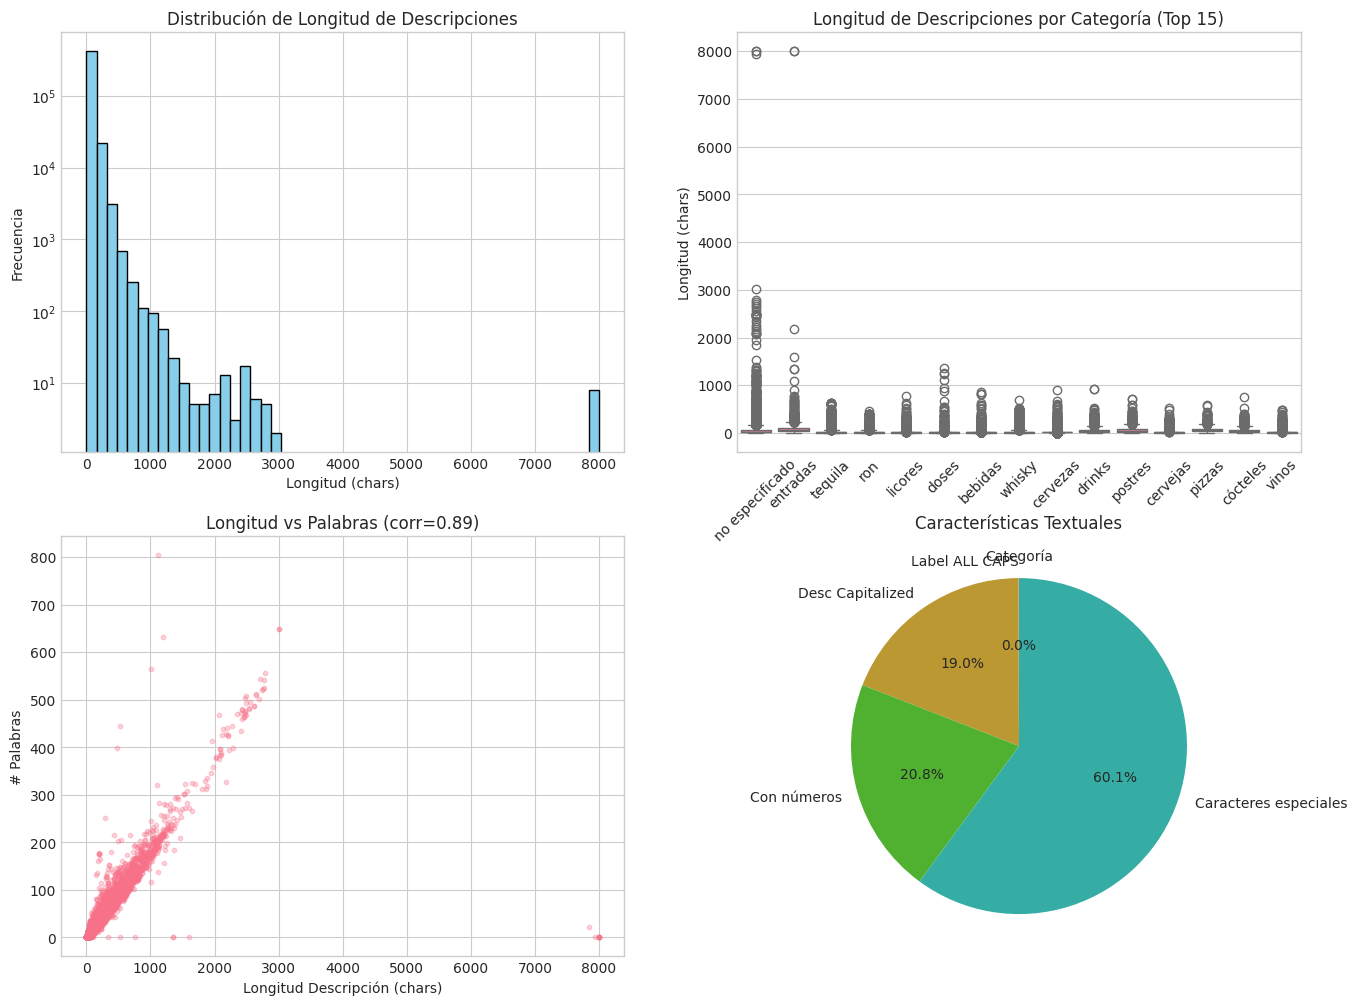

✓ Reporte guardado: ../reports/eda_cluvi/text_analysis.json


In [ ]:
# =============================================================================
# SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES
# =============================================================================
print_section("SECCIÓN 5: ANÁLISIS DE LONGITUDES Y CARACTERÍSTICAS TEXTUALES")
liberar_ram()

text_analysis = {}

# Agregar columnas derivadas para características textuales (si no están ya)
df = df.with_columns([
    (pl.col("label") == pl.col("label").str.to_uppercase()).alias("label_all_caps"),
    (pl.col("description").str.slice(0, 1) == pl.col("description").str.slice(0, 1).str.to_uppercase()).alias("desc_capitalized")
])

# Estadísticas de longitud de descripciones
length_stats = df["description_length_chars"].describe()
print("Estadísticas de longitud de descripciones (chars):")
print(length_stats)

# Longitudes por categoría
length_by_cat = df.group_by("category").agg([
    pl.col("description_length_chars").mean().alias("mean_length"),
    pl.col("description_length_chars").median().alias("median_length"),
    pl.col("description_length_chars").std().alias("std_length"),
    pl.col("description_length_chars").min().alias("min_length"),
    pl.col("description_length_chars").max().alias("max_length"),
    pl.count().alias("count")
]).sort("mean_length", descending=True)

print("\nLongitud de descripciones por categoría:")
print(length_by_cat)

# Categorías con mayor variabilidad
print("\nCategorías con mayor variabilidad en longitud (top 5):")
print(length_by_cat.sort("std_length", descending=True).head(5))

# Análisis de características textuales
print("\n--- Características Textuales ---")
caps_stats = df.select([
    pl.col("label_all_caps").sum().alias("label_all_caps"),
    pl.col("desc_capitalized").sum().alias("desc_capitalized"),
    pl.col("has_numbers").sum().alias("with_numbers"),
    pl.col("has_special_chars").sum().alias("with_special_chars")
])
print(caps_stats)

text_analysis['label_all_caps_pct'] = float(100 * caps_stats["label_all_caps"][0] / total_entries)
text_analysis['desc_capitalized_pct'] = float(100 * caps_stats["desc_capitalized"][0] / total_entries)
text_analysis['with_numbers_pct'] = float(100 * caps_stats["with_numbers"][0] / total_entries)
text_analysis['with_special_chars_pct'] = float(100 * caps_stats["with_special_chars"][0] / total_entries)

# Descripciones muy cortas (posibles errores)
very_short = df.filter(pl.col("description_length_chars") <= 10)
print(f"\nDescripciones muy cortas (≤10 chars): {len(very_short)} ({100*len(very_short)/total_entries:.2f}%)")
print("Ejemplos:")
print(very_short.head(10).select(["label", "category", "description_length_chars"]))

# Descripciones muy largas
very_long = df.filter(pl.col("description_length_chars") > 500)
print(f"\nDescripciones muy largas (>500 chars): {len(very_long)}")
if len(very_long) > 0:
    print("Top 5 más largas:")
    print(very_long.sort("description_length_chars", descending=True).head(5).select(["label", "category", "description_length_chars"]))

# Correlación longitud descripción vs num palabras
corr_length_words = df.select([
    pl.corr("description_length_chars", "num_words_description").alias("corr")
]).item()
print(f"\nCorrelación longitud descripción vs # palabras: {corr_length_words:.3f}")
text_analysis['corr_desc_length_num_words'] = float(corr_length_words)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histograma de longitudes de descripciones (con escala log)
axes[0,0].hist(df["description_length_chars"].to_numpy(), bins=50, color='skyblue', edgecolor='black')
axes[0,0].set_xlabel("Longitud (chars)")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].set_title("Distribución de Longitud de Descripciones")
axes[0,0].set_yscale('log')

# Boxplot por categoría (top 15 categorías)
top_15_cats = cat_dist.head(15)["category"].to_list()
data_top15 = df.filter(pl.col("category").is_in(top_15_cats))
sns.boxplot(data=data_top15.to_pandas(), x="category", y="description_length_chars", ax=axes[0,1])
axes[0,1].set_xlabel("Categoría")
axes[0,1].set_ylabel("Longitud (chars)")
axes[0,1].set_title("Longitud de Descripciones por Categoría (Top 15)")
axes[0,1].tick_params(axis='x', rotation=45)

# Scatter: longitud descripción vs # palabras
scatter_data = df.to_pandas()
axes[1,0].scatter(scatter_data["description_length_chars"], scatter_data["num_words_description"], alpha=0.3, s=10)
axes[1,0].set_xlabel("Longitud Descripción (chars)")
axes[1,0].set_ylabel("# Palabras")
axes[1,0].set_title(f"Longitud vs Palabras (corr={corr_length_words:.2f})")

# Pie chart de características textuales
char_features = [
    caps_stats["label_all_caps"][0],
    caps_stats["desc_capitalized"][0],
    caps_stats["with_numbers"][0],
    caps_stats["with_special_chars"][0]
]
labels = ['Label ALL CAPS', 'Desc Capitalized', 'Con números', 'Caracteres especiales']
axes[1,1].pie(char_features, labels=labels, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title("Características Textuales")

plot_and_save(fig, 'text_analysis.png')

save_report(text_analysis, 'text_analysis.json')

In [ ]:
# =============================================================================
# SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS Y CONTEXTO
# =============================================================================
print_section("SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS")
liberar_ram()

cooccurrence_report = {}

# Co-ocurrencia de category y main_category
print("\n--- Co-ocurrencias de Category y Main_Category ---")
cooccurrence = df.select(["label", "category", "main_category"]).filter(
    pl.col("category") != pl.col("main_category")
).group_by(["category", "main_category"]).agg(
    pl.count().alias("count")
).sort("count", descending=True)

print("Top 20 pares de category-main_category:")
print(cooccurrence.head(20))

# Guardar top 50
save_report(cooccurrence.head(50).to_pandas(), 'cooccurrences.csv', 'csv')

cooccurrence_report['total_cooccurrence_pairs'] = len(cooccurrence)

# Distribución por main_category
print("\n--- Distribución por Main_Category ---")
main_pos_dist = df.group_by(["main_category", "category"]).agg(
    pl.count().alias("count")
).sort(["main_category", "count"], descending=[False, True])

print("Distribución de categorías por main_category (top 10 main):")
top10_main = main_cat_dist.head(10)["main_category"].to_list()
print(main_pos_dist.filter(pl.col("main_category").is_in(top10_main)))

save_report(cooccurrence_report, 'cooccurrence_report.json')


SECCIÓN 6: ANÁLISIS DE CO-OCURRENCIAS
RAM liberada: 225.21 MB
RAM actual: 2473.12 MB

--- Co-ocurrencias de Category y Main_Category ---
Top 20 pares de category-main_category:
shape: (20, 3)
┌──────────────────┬─────────────────┬───────┐
│ category         ┆ main_category   ┆ count │
│ ---              ┆ ---             ┆ ---   │
│ str              ┆ str             ┆ u32   │
╞══════════════════╪═════════════════╪═══════╡
│ bebidas          ┆ no especificado ┆ 2129  │
│ cervezas         ┆ bebidas         ┆ 1382  │
│ whisky           ┆ licores         ┆ 1303  │
│ cervezas         ┆ no especificado ┆ 1124  │
│ doses            ┆ destilados      ┆ 1049  │
│ …                ┆ …               ┆ …     │
│ entradas         ┆ comidas         ┆ 583   │
│ licores          ┆ no especificado ┆ 565   │
│ petiscos         ┆ pratos          ┆ 515   │
│ drinks clássicos ┆ drinks          ┆ 513   │
│ vodka            ┆ licores         ┆ 510   │
└──────────────────┴─────────────────┴───────┘
✓ Report


SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
RAM liberada: 0.00 MB
RAM actual: 2473.77 MB
Preparando datos para clustering...
Generando dendrograma...
✓ Gráfico guardado: ../reports/eda_cluvi/dendrogram.png


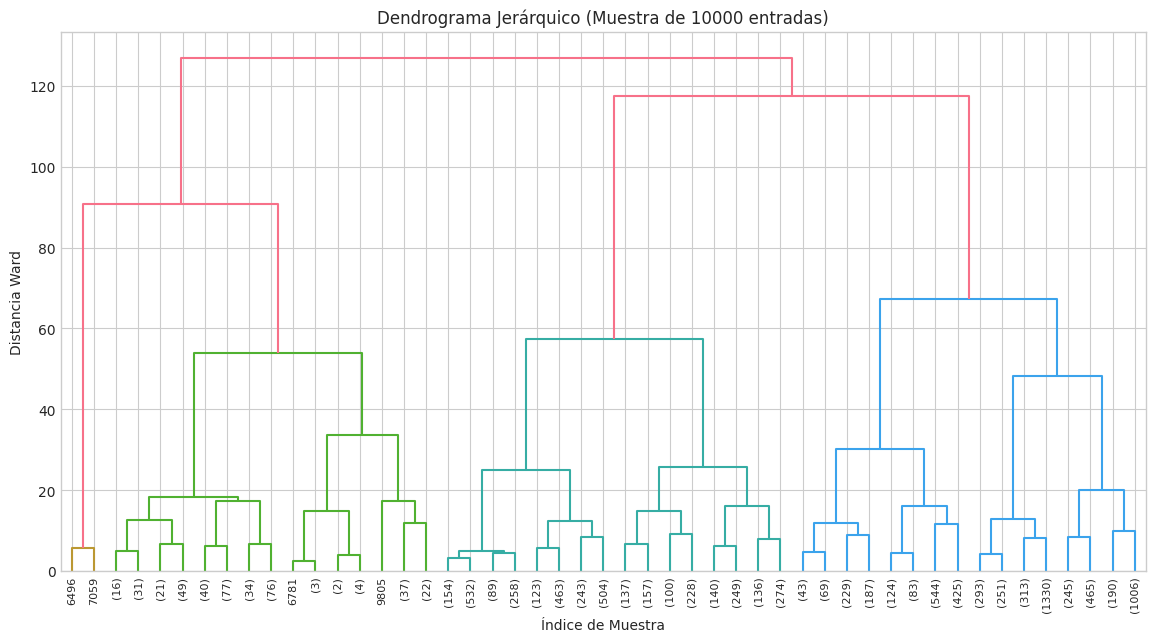

Calculando método del codo...
✓ Gráfico guardado: ../reports/eda_cluvi/elbow_method.png


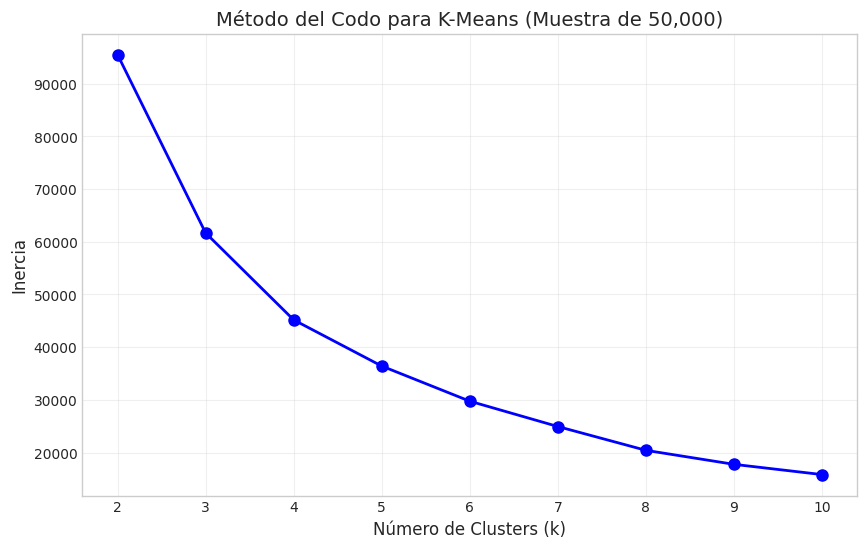


Aplicando Mini-Batch K-Means con k=4...

Distribución de categorías por cluster:
category  \t small plates*  \t vermutes/run  \tclássicos & autorais\t  \
cluster                                                                 
0                        0                0                         0   
1                        0                0                         0   
2                       16                5                        12   
3                        0                0                         0   

category  \tcomidas  \tpostres / desserts\t  \tsingle malt / blended malt  \
cluster                                                                     
0                 0                       0                             0   
1                 0                       0                             0   
2                 1                       1                             3   
3                 0                       1                             0   

category        

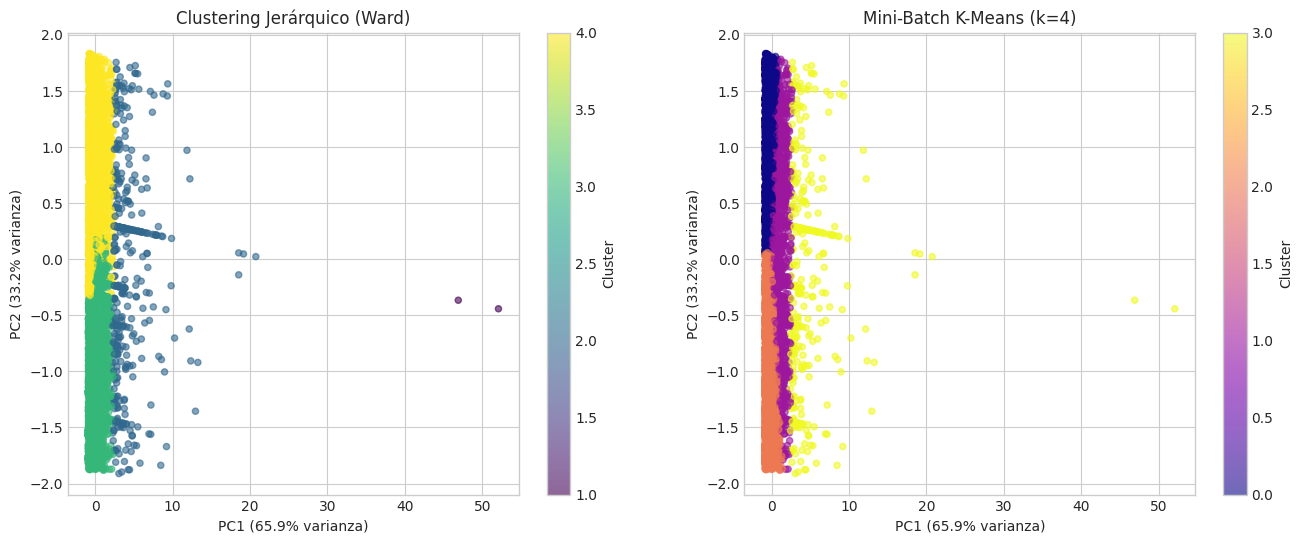

✓ Reporte guardado: ../reports/eda_cluvi/clustering_report.json


In [ ]:
# =============================================================================
# SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN
# =============================================================================
print_section("SECCIÓN 7: CLUSTERING Y SEGMENTACIÓN")
liberar_ram()

clustering_report = {}

# Preparación de datos para clustering
print("Preparando datos para clustering...")
df_cluster_full = df.select([
    "description_length_chars", "num_words_description", "category"
]).to_pandas()

# Encode categóricas
le_cat = LabelEncoder().fit(df_cluster_full["category"])
df_cluster_full["category_encoded"] = le_cat.transform(df_cluster_full["category"])

features_full = df_cluster_full[["description_length_chars", "num_words_description", "category_encoded"]].values
scaler = StandardScaler()
features_scaled_full = scaler.fit_transform(features_full)

# Muestreo estratificado para dendrograma
sample_size = 10000
df_sample = df.sample(n=min(sample_size, len(df)), seed=42).to_pandas()
df_sample["category_encoded"] = le_cat.transform(df_sample["category"])
features_sample = df_sample[["description_length_chars", "num_words_description", "category_encoded"]].values
features_scaled_sample = scaler.transform(features_sample)

# Dendrograma jerárquico
print("Generando dendrograma...")
Z = linkage(features_scaled_sample, method='ward')
fig, ax = plt.subplots(figsize=(14, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, ax=ax)
ax.set_title(f"Dendrograma Jerárquico (Muestra de {len(df_sample)} entradas)")
ax.set_xlabel("Índice de Muestra")
ax.set_ylabel("Distancia Ward")
plot_and_save(fig, 'dendrogram.png')

# Método del codo
print("Calculando método del codo...")
elbow_sample_size = min(50000, len(features_scaled_full))
elbow_indices = np.random.choice(len(features_scaled_full), elbow_sample_size, replace=False)
features_elbow = features_scaled_full[elbow_indices]

inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_elbow)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (k)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title(f'Método del Codo para K-Means (Muestra de {elbow_sample_size:,})', fontsize=14)
ax.grid(True, alpha=0.3)
plot_and_save(fig, 'elbow_method.png')

# K-Means óptimo (asumimos k=4 basado en elbow, ajusta según visualización)
k_opt = 4
print(f"\nAplicando Mini-Batch K-Means con k={k_opt}...")
mb_kmeans = MiniBatchKMeans(n_clusters=k_opt, random_state=42, batch_size=1024, n_init=3)
mb_kmeans.fit(features_scaled_full)
df_cluster_full['cluster'] = mb_kmeans.labels_

# Análisis de clusters
cluster_summary = df_cluster_full.groupby(['cluster', 'category']).size().unstack(fill_value=0)
print("\nDistribución de categorías por cluster:")
print(cluster_summary)

cluster_means = df_cluster_full.groupby('cluster').agg({
    'description_length_chars': ['mean', 'std', 'min', 'max'],
    'category': 'count'
})
print("\nEstadísticas por cluster:")
print(cluster_means)

clustering_report['optimal_k'] = k_opt
clustering_report['inertias'] = {int(k): float(inertia) for k, inertia in zip(K_range, inertias)}

# PCA para visualización
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Clusters jerárquicos
num_clusters_hier = 4
clusters_hier = fcluster(Z, t=num_clusters_hier, criterion='maxclust')
scatter1 = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=clusters_hier, cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[0].set_title('Clustering Jerárquico (Ward)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Plot 2: K-Means en muestra
df_sample['cluster_kmeans'] = mb_kmeans.predict(features_scaled_sample)
scatter2 = axes[1].scatter(features_pca[:, 0], features_pca[:, 1], 
                           c=df_sample['cluster_kmeans'], cmap='plasma', alpha=0.6, s=20)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
axes[1].set_title(f'Mini-Batch K-Means (k={k_opt})')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plot_and_save(fig, 'clustering_pca.png')

save_report(clustering_report, 'clustering_report.json')


SECCIÓN 8: ANÁLISIS DE CORRELACIONES
RAM liberada: 7.84 MB
RAM actual: 2502.03 MB
✓ Gráfico guardado: ../reports/eda_cluvi/correlation_matrix.png


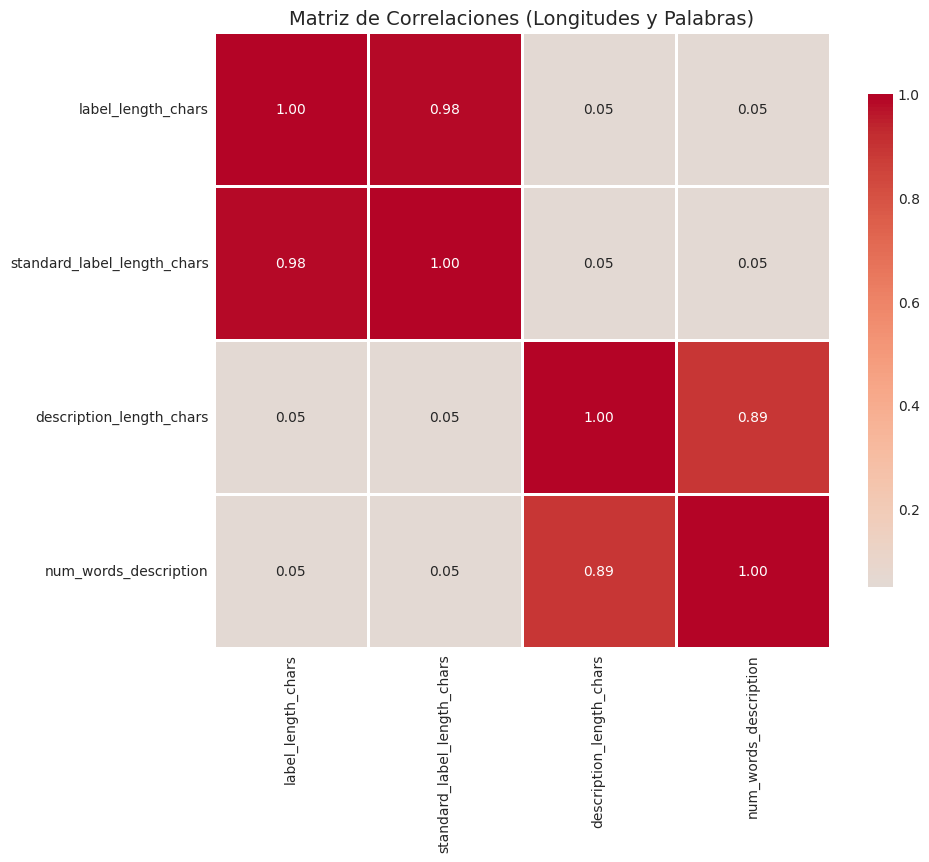


Correlaciones más fuertes (|r| > 0.5, excluyendo diagonales):
  label_length_chars <-> standard_label_length_chars: 0.982
  description_length_chars <-> num_words_description: 0.892


In [ ]:
# =============================================================================
# SECCIÓN 8: ANÁLISIS DE CORRELACIONES
# =============================================================================
print_section("SECCIÓN 8: ANÁLISIS DE CORRELACIONES")
liberar_ram()

# Correlaciones numéricas
corr_cols = ["label_length_chars", "standard_label_length_chars", "description_length_chars", "num_words_description"]
corr_df = df.select(corr_cols).to_pandas().corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Matriz de Correlaciones (Longitudes y Palabras)", fontsize=14)
plot_and_save(fig, 'correlation_matrix.png')

# Correlaciones destacables
print("\nCorrelaciones más fuertes (|r| > 0.5, excluyendo diagonales):")
corr_pairs = []
for i in range(len(corr_df.columns)):
    for j in range(i+1, len(corr_df.columns)):
        corr_val = corr_df.iloc[i, j]
        if abs(corr_val) > 0.5:
            corr_pairs.append({
                'var1': corr_df.columns[i],
                'var2': corr_df.columns[j],
                'correlation': corr_val
            })

for pair in sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
    print(f"  {pair['var1']} <-> {pair['var2']}: {pair['correlation']:.3f}")

In [ ]:
# =============================================================================
# SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS
# =============================================================================
print_section("SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS")

label_analysis = {}

# Top labels más frecuentes (si hay duplicados)
print("\n--- Top 20 Labels Más Frecuentes ---")
label_freq = df.group_by("label").agg([
    pl.count().alias("frequency"),
    pl.col("category").first().alias("category")
]).sort("frequency", descending=True)

print(label_freq.head(20))

# Labels que aparecen con un solo categoría vs múltiples
label_cat_variety = df.group_by("label").agg([
    pl.col("category").n_unique().alias("num_categories"),
    pl.count().alias("total_occurrences")
])

single_cat = label_cat_variety.filter(pl.col("num_categories") == 1)
multi_cat = label_cat_variety.filter(pl.col("num_categories") > 1)

print(f"\nLabels con categoría única: {len(single_cat)} ({100*len(single_cat)/len(label_cat_variety):.1f}%)")
print(f"Labels con múltiples categorías: {len(multi_cat)} ({100*len(multi_cat)/len(label_cat_variety):.1f}%)")

label_analysis['single_cat_labels'] = len(single_cat)
label_analysis['multi_cat_labels'] = len(multi_cat)

# Análisis de capitalización por categoría
caps_by_cat = df.group_by("category").agg([
    pl.col("label_all_caps").mean().alias("pct_label_all_caps"),
    pl.col("has_numbers").mean().alias("pct_with_numbers")
]).sort("pct_label_all_caps", descending=True)

print("\nCaracterísticas textuales por categoría (top 10):")
print(caps_by_cat.head(10))

# Palabras más comunes en descripciones
print("\n--- Análisis de Palabras en Descripciones ---")
all_words = df["description_lower"].str.split(" ").explode()
word_freq = all_words.value_counts().head(30)
print("Top 30 palabras más frecuentes en descripciones:")
print(word_freq)

save_report(label_analysis, 'label_analysis.json')


SECCIÓN 9: ANÁLISIS DE LABELS ESPECÍFICAS

--- Top 20 Labels Más Frecuentes ---
shape: (20, 3)
┌────────────────────┬───────────┬──────────────────────┐
│ label              ┆ frequency ┆ category             │
│ ---                ┆ ---       ┆ ---                  │
│ str                ┆ u32       ┆ str                  │
╞════════════════════╪═══════════╪══════════════════════╡
│ corona             ┆ 1267      ┆ cervezas             │
│ heineken           ┆ 1050      ┆ cervejas 600ml       │
│ margarita          ┆ 1038      ┆ pizzas tradicionales │
│ stella artois      ┆ 1038      ┆ cervezas             │
│ mojito             ┆ 1028      ┆ cócteles             │
│ …                  ┆ …         ┆ …                    │
│ ketel one          ┆ 547       ┆ vodka                │
│ licor 43           ┆ 528       ┆ no especificado      │
│ smirnoff           ┆ 521       ┆ doses vodka          │
│ americano          ┆ 505       ┆ café y té            │
│ don julio reposado ┆ 502       ┆


Labels con categoría única: 159425 (80.2%)
Labels con múltiples categorías: 39381 (19.8%)

Características textuales por categoría (top 10):
shape: (10, 3)
┌─────────────────────────────┬────────────────────┬──────────────────┐
│ category                    ┆ pct_label_all_caps ┆ pct_with_numbers │
│ ---                         ┆ ---                ┆ ---              │
│ str                         ┆ f64                ┆ f64              │
╞═════════════════════════════╪════════════════════╪══════════════════╡
│ información de alérgenos    ┆ 1.0                ┆ 0.0              │
│ paquetito                   ┆ 1.0                ┆ 1.0              │
│ información sobre alérgenos ┆ 1.0                ┆ 0.0              │
│ adiciones-                  ┆ 1.0                ┆ 0.0              │
│ pruebas                     ┆ 1.0                ┆ 0.0              │
│ adiciones¡                  ┆ 1.0                ┆ 0.0              │
│ gelo de coco                ┆ 1.0                

In [ ]:
# =============================================================================
# SECCIÓN 10: CASOS EXTREMOS Y MUESTRAS PARA REVISIÓN MANUAL
# =============================================================================
print_section("SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL")

extreme_cases = {}

# 1. Descripciones más largas
print("\n--- Top 15 Descripciones Más Largas ---")
longest_desc = df.sort("description_length_chars", descending=True).head(15).select([
    "label", "description", "category", "description_length_chars"
])
print(longest_desc)
save_report(longest_desc.to_pandas(), 'longest_descriptions.csv', 'csv')

# 2. Descripciones más cortas (posibles errores)
print("\n--- Descripciones Más Cortas (≤5 chars) ---")
shortest_desc = df.filter(pl.col("description_length_chars") <= 5).head(20).select([
    "label", "description", "category"
])
print(shortest_desc)
extreme_cases['short_desc_entities'] = len(df.filter(pl.col("description_length_chars") <= 5))

# 3. Categorías con más entradas
print("\n--- Top 10 Categorías Con Más Entradas ---")
most_entries = df.group_by("category").agg(pl.count().alias("num_entries")).sort("num_entries", descending=True).head(10)
print(most_entries)

# Obtener muestras de estas categorías para inspección
if len(most_entries) > 0:
    top_cat_names = most_entries["category"].to_list()
    top_samples = df.filter(pl.col("category").is_in(top_cat_names)).group_by("category").head(1).select([
        "label", "description", "category"
    ])
    
    print("\nMuestra de 5 categorías con más entradas:")
    print(top_samples.head(5))

# 4. Labels con caracteres especiales inusuales
print("\n--- Labels con Caracteres Especiales ---")
special_char_labels = df.filter(
    pl.col("label").str.contains(r"[^\w\s\-']")  # No alfanumérico, espacio, guión o apóstrofo
).head(20).select(["label", "category"])
print(special_char_labels)
extreme_cases['labels_with_special_chars'] = len(df.filter(
    pl.col("label").str.contains(r"[^\w\s\-']")
))

# 5. Labels numéricas puras
print("\n--- Labels Numéricas Puras ---")
numeric_labels = df.filter(
    pl.col("label").str.contains(r"^\d+$")
).head(20).select(["label", "category"])
print(numeric_labels)
extreme_cases['pure_numeric_labels'] = len(df.filter(
    pl.col("label").str.contains(r"^\d+$")
))

save_report(extreme_cases, 'extreme_cases.json')


SECCIÓN 10: CASOS EXTREMOS PARA REVISIÓN MANUAL

--- Top 15 Descripciones Más Largas ---
shape: (15, 4)
┌──────────────────────────┬─────────────────────────┬───────────────────┬─────────────────────────┐
│ label                    ┆ description             ┆ category          ┆ description_length_char │
│ ---                      ┆ ---                     ┆ ---               ┆ s                       │
│ str                      ┆ str                     ┆ str               ┆ ---                     │
│                          ┆                         ┆                   ┆ u32                     │
╞══════════════════════════╪═════════════════════════╪═══════════════════╪═════════════════════════╡
│ croquetas de  salmón     ┆ <img src="data:image/pn ┆ entradas          ┆ 7997                    │
│ (salmon c…               ┆ g;base6…                ┆                   ┆                         │
│ stella artois            ┆ <img src="data:image/pn ┆ no especificado   ┆ 7997        


SECCIÓN 11: RESUMEN EJECUTIVO

RESUMEN EJECUTIVO
{
  "dataset_overview": {
    "total_entries": 444071,
    "unique_labels": 198806,
    "unique_categories": 26901,
    "num_main_categories": 8829,
    "coverage_top_main_cat": [
      {
        "main_category": "no especificado",
        "count": 149184,
        "coverage_pct": 33.59462788608128
      },
      {
        "main_category": "bebidas",
        "count": 35844,
        "coverage_pct": 8.071682230994593
      },
      {
        "main_category": "licores",
        "count": 13933,
        "coverage_pct": 3.1375613359125003
      },
      {
        "main_category": "drinks",
        "count": 10704,
        "coverage_pct": 2.410425359908663
      },
      {
        "main_category": "comidas",
        "count": 9431,
        "coverage_pct": 2.123759488910557
      }
    ]
  },
  "quality_metrics": {
    "null_counts": {
      "label": 0,
      "standard_label": 0,
      "description": 0,
      "category": 0,
      "main_category": 

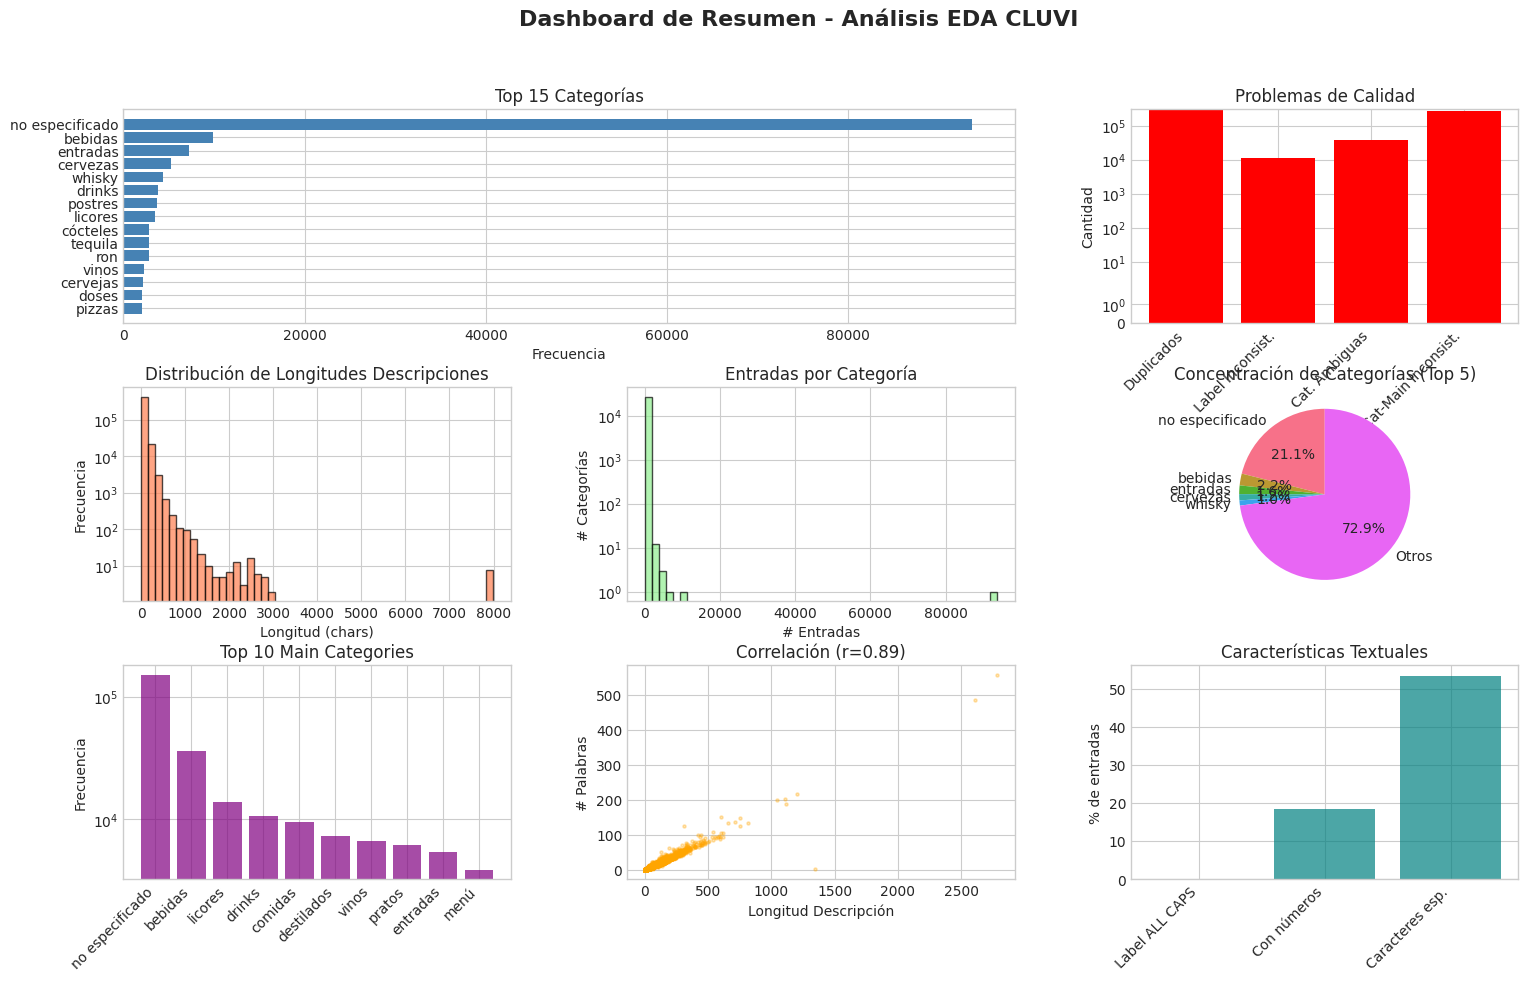

In [ ]:
# =============================================================================
# SECCIÓN 11: RESUMEN EJECUTIVO Y EXPORTACIÓN FINAL
# =============================================================================
print_section("SECCIÓN 11: RESUMEN EJECUTIVO")

executive_summary = {
    "dataset_overview": {
        "total_entries": total_entries,
        "unique_labels": unique_labels,
        "unique_categories": unique_categories,
        "num_main_categories": len(main_cat_dist),
        "coverage_top_main_cat": basic_stats.get('coverage_top_main_cat', []),
    },
    "quality_metrics": quality_report,
    "imbalance_metrics": {
        "gini_coefficient": float(gini),
        "entropy": float(ent),
        "max_min_ratio": float(max_ratio)
    },
    "top_5_categories": cat_dist.head(5).to_pandas().to_dict('records'),
    "length_statistics": {
        "mean_desc_length": float(df["description_length_chars"].mean()),
        "median_desc_length": float(df["description_length_chars"].median()),
        "max_desc_length": int(df["description_length_chars"].max()),
        "mean_label_length": float(df["label_length_chars"].mean())
    },
    "category_validation": category_report,
    "clustering": {
        "optimal_clusters": k_opt,
        "pca_variance_explained": float(pca.explained_variance_ratio_.sum())
    },
    "extreme_cases": extreme_cases,
    "recommendations": [
        "Revisar labels duplicados" if quality_report.get('duplicates', 0) > 0 else "✓ No hay duplicados",
        "Resolver inconsistencias label vs standard_label" if quality_report.get('label_inconsistencies', 0) > 0 else "✓ Labels consistentes",
        "Resolver labels ambiguos con múltiples categorías" if quality_report.get('ambiguous_categories', 0) > 0 else "✓ No hay ambigüedades",
        "Validar diferencias category vs main_category" if category_report.get('category_inconsistencies', 0) > 0 else "✓ Categorías consistentes",
        f"Considerar estratificación por categoría (Gini={gini:.2f})" if gini > 0.6 else "✓ Balance aceptable de categorías",
        "Revisar descripciones de ≤5 chars" if extreme_cases.get('short_desc_entities', 0) > 100 else "✓ Pocas descripciones cortas"
    ]
}

print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)
print(json.dumps(executive_summary, indent=2, ensure_ascii=False))

save_report(executive_summary, 'executive_summary.json')

# Gráfico de resumen final
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribución de categorías (barras horizontales, top 15)
ax1 = fig.add_subplot(gs[0, :2])
top15_dist = cat_dist.head(15).to_pandas()

# Eliminar filas donde category es None o NaN para evitar errores en el gráfico
top15_dist = top15_dist[top15_dist["category"].notnull()]

# Convertir category a string explícitamente (por si acaso)
top15_dist["category"] = top15_dist["category"].astype(str)

ax1.barh(top15_dist["category"], top15_dist["count"], color='steelblue')
ax1.set_xlabel("Frecuencia")
ax1.set_title("Top 15 Categorías")
ax1.invert_yaxis()

# 2. Métricas de calidad
ax2 = fig.add_subplot(gs[0, 2])
quality_metrics = [
    quality_report.get('duplicates', 0),
    quality_report.get('label_inconsistencies', 0),
    quality_report.get('ambiguous_categories', 0),
    category_report.get('category_inconsistencies', 0)
]
quality_labels = ['Duplicados', 'Label Inconsist.', 'Cat. Ambiguas', 'Cat-Main Inconsist.']
colors_quality = ['red' if m > 0 else 'green' for m in quality_metrics]
ax2.bar(range(len(quality_metrics)), quality_metrics, color=colors_quality)
ax2.set_xticks(range(len(quality_labels)))
ax2.set_xticklabels(quality_labels, rotation=45, ha='right')
ax2.set_ylabel("Cantidad")
ax2.set_title("Problemas de Calidad")
ax2.set_yscale('symlog')

# 3. Distribución de longitudes de descripciones
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df["description_length_chars"].to_numpy(), bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel("Longitud (chars)")
ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de Longitudes Descripciones")
ax3.set_yscale('log')

# 4. Entradas por categoría
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df.group_by("category").agg(pl.count())["count"].to_numpy(), bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax4.set_xlabel("# Entradas")
ax4.set_ylabel("# Categorías")
ax4.set_title("Entradas por Categoría")
ax4.set_yscale('log')

# 5. Desbalance (pie chart)
ax5 = fig.add_subplot(gs[1, 2])
top5_counts = cat_dist.head(5)["count"].to_numpy()
others = cat_dist["count"].sum() - top5_counts.sum()
pie_data = list(top5_counts) + [others]
pie_labels = cat_dist.head(5)["category"].to_list() + ['Otros']
ax5.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax5.set_title("Concentración de Categorías (Top 5)")

# 6. Distribución de main_categories
ax6 = fig.add_subplot(gs[2, 0])
main_top = main_cat_dist.head(10).to_pandas()
ax6.bar(range(len(main_top)), main_top["count"], color='purple', alpha=0.7)
ax6.set_xticks(range(len(main_top)))
ax6.set_xticklabels(main_top["main_category"], rotation=45, ha='right')
ax6.set_ylabel("Frecuencia")
ax6.set_title("Top 10 Main Categories")
ax6.set_yscale('log')

# 7. Correlación longitud-palabras
ax7 = fig.add_subplot(gs[2, 1])
scatter_sample = df.sample(n=min(10000, len(df)), seed=42).to_pandas()
ax7.scatter(scatter_sample["description_length_chars"], scatter_sample["num_words_description"], 
            alpha=0.3, s=5, color='orange')
ax7.set_xlabel("Longitud Descripción")
ax7.set_ylabel("# Palabras")
ax7.set_title(f"Correlación (r={corr_length_words:.2f})")

# 8. Características textuales
ax8 = fig.add_subplot(gs[2, 2])
char_features_pct = [
    100 * caps_stats["label_all_caps"][0] / total_entries,
    100 * caps_stats["with_numbers"][0] / total_entries,
    100 * caps_stats["with_special_chars"][0] / total_entries,
]
char_labels = ['Label ALL CAPS', 'Con números', 'Caracteres esp.']
ax8.bar(range(len(char_features_pct)), char_features_pct, color='teal', alpha=0.7)
ax8.set_xticks(range(len(char_labels)))
ax8.set_xticklabels(char_labels, rotation=45, ha='right')
ax8.set_ylabel("% de entradas")
ax8.set_title("Características Textuales")

fig.suptitle("Dashboard de Resumen - Análisis EDA CLUVI", fontsize=16, fontweight='bold')
plot_and_save(fig, 'executive_dashboard.png')

In [ ]:
# =============================================================================
# FINALIZACIÓN
# =============================================================================
print("\n" + "="*80)
print("✓ EDA COMPLETADO EXITOSAMENTE")
print("="*80)
print(f"\nReportes generados en: {REPORT_DIR}")
print("\nArchivos creados:")
for report_file in sorted(REPORT_DIR.glob("*")):
    print(f"  - {report_file.name}")

print("\n" + "="*80)
print("RECOMENDACIONES FINALES:")
print("="*80)
for i, rec in enumerate(executive_summary['recommendations'], 1):
    print(f"{i}. {rec}")

print("\n¡Análisis completado! Revisa los reportes y visualizaciones generadas.")
print("="*80)


✓ EDA COMPLETADO EXITOSAMENTE

Reportes generados en: ../reports/eda_cluvi

Archivos creados:
  - ambiguous_categories.csv
  - basic_stats.json
  - category_distribution.png
  - category_stats.json
  - category_validation_report.json
  - clustering_pca.png
  - clustering_report.json
  - cooccurrence_report.json
  - cooccurrences.csv
  - correlation_matrix.png
  - dendrogram.png
  - elbow_method.png
  - executive_dashboard.png
  - executive_summary.json
  - extreme_cases.json
  - label_analysis.json
  - longest_descriptions.csv
  - quality_report.json
  - text_analysis.json
  - text_analysis.png

RECOMENDACIONES FINALES:
1. Revisar labels duplicados
2. Resolver inconsistencias label vs standard_label
3. Resolver labels ambiguos con múltiples categorías
4. Validar diferencias category vs main_category
5. Considerar estratificación por categoría (Gini=0.83)
6. Revisar descripciones de ≤5 chars

¡Análisis completado! Revisa los reportes y visualizaciones generadas.
